# P0 · Read real model Python

Unit 0 foundations for the current Tiny Transformer and the later Phyll course. Basic Python variables, loops and functions are assumed.

Download and open this notebook in Jupyter, or choose **File → Upload notebook** in Google Colab. All examples and the required helper code are included. No account key, private repository, GPU or dataset download is needed.

Examples are **illustrative**, executed with Python. Newly constructed model weights are explicitly untrained. Run from a fresh kernel in order. Each exercise can run before you fill it in; open its folded solution afterward.

The `show` helper prints named intermediate results. It is course code, not a built-in Python or PyTorch function.

In [1]:
import sys
print("Python", sys.version.split()[0])
print("Self-contained notebook. Run top to bottom; no repository clone or API key.")


Python 3.12.3
Self-contained notebook. Run top to bottom; no repository clone or API key.


Publication destination: the [public course labs repository](https://github.com/gkiri/tiny_repo). This notebook includes its own examples and can run before that mirror is published.

In [2]:
#@title Display helper: print and draw executed values { display-mode: "form" }
"""Small display helper embedded verbatim in independent notebooks; traces record real executions."""
import json
import math

FRAMES = []


def plain(value):
    if hasattr(value, "detach"):
        return plain(value.detach().cpu().tolist())
    if isinstance(value, dict):
        return {str(k): plain(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [plain(v) for v in value]
    if isinstance(value, float) and not math.isfinite(value):
        return str(value)
    if value is None or isinstance(value, (str, int, float, bool)):
        return value
    return str(value)


def show(label, value):
    """Print and snapshot an intermediate. This helper is course code, not a PyTorch API."""
    frame = {"label": label, "value": plain(value)}
    if hasattr(value, "shape"):
        frame.update(shape=list(value.shape), dtype=str(value.dtype), device=str(value.device))
    FRAMES.append(frame)
    print(label + ":", json.dumps(frame["value"], ensure_ascii=False))
    if "shape" in frame:
        print("  shape", frame["shape"], "·", frame["dtype"], "·", frame["device"])


def draw_trace():
    """A portable SVG trace diagram; requires only the notebook's existing IPython display."""
    import html
    from IPython.display import SVG, display
    height = 82 * len(FRAMES) + 12
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 720 {height}" role="img" aria-label="Executed intermediate values">']
    for i, frame in enumerate(FRAMES):
        y = 8 + 82*i
        value = json.dumps(frame["value"], ensure_ascii=False)
        if len(value) > 91:
            value = value[:88] + "…"
        parts += [f'<rect x="4" y="{y}" width="708" height="68" rx="10" fill="#f4f8ef" stroke="#779861"/>',
                  f'<text x="20" y="{y+25}" font-size="15" font-family="sans-serif" fill="#31524b">{i+1}. {html.escape(frame["label"])}</text>',
                  f'<text x="20" y="{y+48}" font-size="12" font-family="monospace" fill="#252a33">{html.escape(value)}</text>']
        if i + 1 < len(FRAMES):
            parts.append(f'<path d="M360 {y+68} v14" stroke="#7042a6" stroke-width="2"/>')
    display(SVG("".join(parts) + "</svg>"))

## P0.9 · Read real model Python

Inheritance extends behavior; composition stores collaborating objects; decorators modify definitions.

**Prerequisites:** Classes and instances

**Predict:** Which object supplies PyTorch’s call-to-forward behavior?

**Mental model:** A model file can look unfamiliar even when its calculations are small. Separate Python's object machinery from the numerical operations the library provides.

### P0.9.1 · Understand the need

A model file can look unfamiliar even when its calculations are small. Separate Python's object machinery from the numerical operations the library provides.

A configuration object names settings such as width and head count. A data class generates routine initialization from declared fields.

Inheritance gives a class access to behavior defined by a parent. Super lets a method cooperate with that inherited behavior.

An instance can be callable when its class provides a call method. In PyTorch, the module's call machinery dispatches to your forward method and manages hooks.

You only need to read the decorators used by this course. Writing a general decorator framework is a separate programming topic.

### P0.9.2 · Follow the values

Create a configuration with width four and two heads. Converting it to a dictionary makes the named settings visible.

The child operation initializes its inherited amount from the configuration width. This is object state, not a tensor axis being calculated.

Calling the child on three first adds four and then doubles the result, giving fourteen. Changing width to eight changes this result to twenty-two.

A star unpacks the tuple two and three into positional arguments. Power receives two arguments and returns eight.

The configuration still holds its original named settings after these calculations. Computed data and configuration are different objects with different purposes.

In [3]:
FRAMES.clear()
change = 0
from dataclasses import dataclass, asdict
@dataclass(frozen=True)
class Config:
    width: int = 4
    heads: int = 2
class Add:
    def __init__(self, amount):
        self.amount = amount
    def __call__(self, value):
        return value + self.amount
class TwiceAdd(Add):
    def __init__(self, amount):
        super().__init__(amount)
    def __call__(self, value):
        return super().__call__(value) * 2
cfg = Config(width=8 if change else 4)
show("Configuration fields", asdict(cfg))
operation = TwiceAdd(cfg.width)
show("Inherited instance attribute", operation.amount)
show("Call an instance", operation(3))
values = (2, 3)
show("Unpack positional arguments", pow(*values))
show("Configuration stays separate from data", asdict(cfg))

Configuration fields: {"width": 4, "heads": 2}
Inherited instance attribute: 4
Call an instance: 14
Unpack positional arguments: 8
Configuration stays separate from data: {"width": 4, "heads": 2}


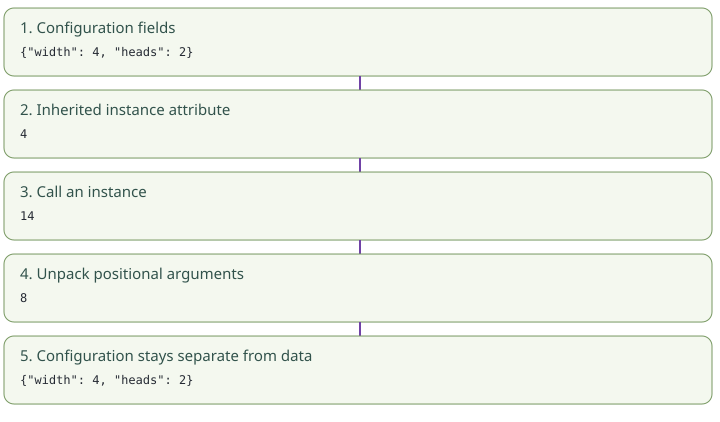

In [4]:
draw_trace()

### P0.9.3 · Read and run the code

The decorator above Config asks dataclass to generate routine class methods. Frozen prevents ordinary reassignment of its declared fields.

The child class names its parent in parentheses. Its initializer uses super to run the parent initialization rather than duplicating it.

The call method makes the instance usable with parentheses. Its behavior is defined here explicitly; a plain class does not acquire a forward convention by itself.

A single star expands positional arguments, while a double star expands keyword mappings. Type annotations describe the intended values without enforcing every constraint at runtime.

Static methods omit an automatic instance argument. Context managers and decorators such as no grad will later control a region of PyTorch execution.

### Change one thing

**Increase configuration width to 8**. Predict which outputs change before running this second case. It executes the same code with `change = 1`.

In [5]:
FRAMES.clear()
change = 1
from dataclasses import dataclass, asdict
@dataclass(frozen=True)
class Config:
    width: int = 4
    heads: int = 2
class Add:
    def __init__(self, amount):
        self.amount = amount
    def __call__(self, value):
        return value + self.amount
class TwiceAdd(Add):
    def __init__(self, amount):
        super().__init__(amount)
    def __call__(self, value):
        return super().__call__(value) * 2
cfg = Config(width=8 if change else 4)
show("Configuration fields", asdict(cfg))
operation = TwiceAdd(cfg.width)
show("Inherited instance attribute", operation.amount)
show("Call an instance", operation(3))
values = (2, 3)
show("Unpack positional arguments", pow(*values))
show("Configuration stays separate from data", asdict(cfg))

Configuration fields: {"width": 8, "heads": 2}
Inherited instance attribute: 8
Call an instance: 22
Unpack positional arguments: 8
Configuration stays separate from data: {"width": 8, "heads": 2}


### A useful distinction

A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.

### ✋ Your turn

Construct Config(width=8, heads=2) and put its width divided by its head count, using integer division, in answer.

In [6]:
answer = None  # TODO: replace with your calculation

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.'
    print("✓ right:", answer)

Your turn: fill in `answer` above, then run this cell again.


In [7]:
#@title Show a solution { display-mode: "form" }
cfg = Config(width=8, heads=2)
answer = cfg.width // cfg.heads

if answer is None:
    print("Your turn: fill in `answer` above, then run this cell again.")
else:
    assert answer == 4, 'A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.'
    print("✓ right:", answer)

✓ right: 4


### P0.9.4 · Find it in the model

The transformer configuration is a data class. The model and block classes inherit from the neural network module base class and initialize it with super.

The model constructs several blocks from the configuration and stores them in a registered container. Star expansion passes the constructed blocks into that container.

The library's model call eventually invokes forward. Calling the model object is the normal entry point because the library has behavior around forward too.

A no-grad decorator changes how operations inside generation are recorded for differentiation. It does not mean the generation function stops performing calculations.

Next, assemble the Python data pipeline and practice reading its contracts from beginning to end.

```python
@dataclass(frozen=True)
class Config:
    d_model: int = 28

class Block(nn.Module):
    def __init__(self, cfg):
        super().__init__()
```

The excerpt illustrates the corresponding operation. Run the complete chapter example above; excerpts can depend on model context.

**Recall:** Which object supplies PyTorch’s call-to-forward behavior?

<details><summary>Check your explanation</summary>

nn.Module. A method named forward is not automatically called by an arbitrary Python class; nn.Module supplies that protocol.

</details>